# GARCH Processes: Volatility That Clusters

Most random processes have a fixed amount of randomness. A GARCH lets the *size of the
swings* change over time, and makes it depend on what just happened:

$$\text{variance}[n] = \omega + \alpha\,X[n-1]^2 + \beta\,\text{variance}[n-1]$$
$$X[n] = \sqrt{\text{variance}[n]}\;\times\;\text{shock}[n]$$

A big move makes the next variance bigger, which makes another big move more likely. So
calm stretches and turbulent stretches come in runs. That is **volatility clustering**, and
it is the most recognisable feature of financial returns -- which is exactly what this model
was invented for.

The values themselves are uncorrelated, like plain noise. It is their **sizes** that are
correlated. That is what separates a GARCH from an [AR](ar_arma_process_demo.ipynb), where
the values are correlated directly.

In [1]:
from symbulate import *

## Create a process and draw a path

The classic model is GARCH(1,1) -- one coefficient of each kind. `arch_coefs` says how
strongly a big move raises the next variance; `garch_coefs` says how much the volatility
level persists.

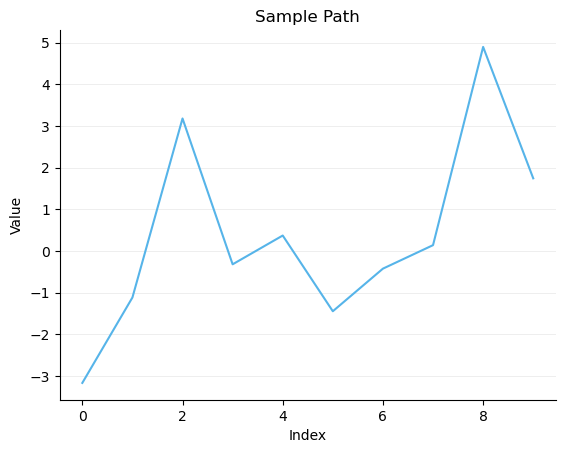

In [2]:
X = GARCH(omega=0.2, arch_coefs=[0.1], garch_coefs=[0.85])
X.draw().plot()

Look for the clustering: stretches where the path is calm, and stretches where it swings
hard. Compare that with plain noise, where the swing size never changes.

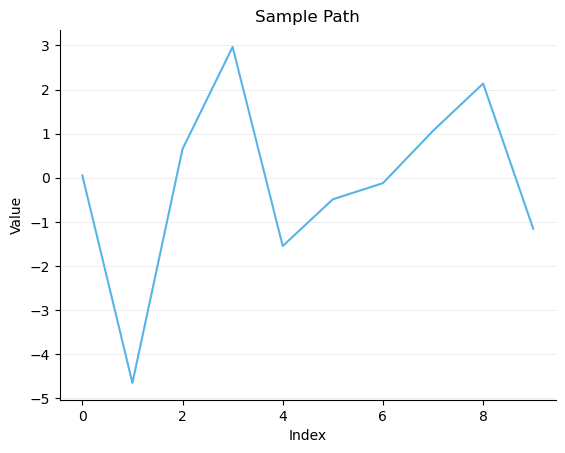

In [3]:
GARCH(omega=4, arch_coefs=[]).draw().plot()   # no feedback: just noise

## Simulate and plot sample paths

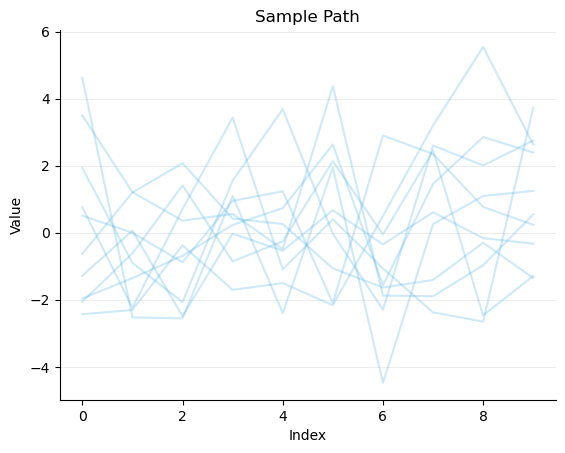

In [4]:
X.sim(10).plot()

## The variance underneath

A GARCH is really a model of the variance; the value is just a standardized shock scaled by
it. `get_variances()` lets you look at the variance path directly.

In [5]:
path = X.draw()
path[60]                       # generate 60 steps first
[round(float(v), 2) for v in path.get_variances()[:12]]

[4.0, 4.51, 4.13, 5.02, 4.54, 4.06, 3.67, 4.18, 3.99, 4.53, 4.65, 5.7]

## The defining property: values uncorrelated, sizes correlated

This is the test that tells a GARCH from anything else. `X[n] & X[n+1]` is the pair of
values at two times; squaring first gives the pair of *sizes*.

In [6]:
print("values  ", round((X[20] & X[21]).sim(10000).corr(), 3), " (expect about 0)")
print("squares ", round(((X[20] ** 2) & (X[21] ** 2)).sim(10000).corr(), 3), " (expect positive)")

Simulating... [█████████████████████████████░] 9816/10000 (98%)

Simulating... [█████████████████████████████░] 9900/10000 (99%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

values   -0.014  (expect about 0)


...

Simulating... [█████████████████████████████░] 9800/10000 (98%)

Simulating... [█████████████████████████████░] 9900/10000 (99%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

squares  0.164  (expect positive)


The values look like noise. The squares do not -- knowing today was a big day tells you
something about tomorrow.

## The long-run variance

When the coefficients sum to less than 1, the variance settles at
$\omega / (1 - \alpha - \beta)$. Symbulate starts the process there by default, so there is
no warm-up period to wait out.

In [7]:
round(X.initial, 2)      # 0.2 / (1 - 0.1 - 0.85)

4.0

In [8]:
for n in [0, 1, 5, 30]:
    print("n =", n, " variance", round(X[n].sim(10000).var(), 2))

n = 0  variance 4.06


n = 1  variance 4.06


n = 5  variance 4.04


Simulating... [████████████████████████░░░░░░] 8228/10000 (82%)

Simulating... [████████████████████████░░░░░░] 8300/10000 (83%)

...

Simulating... [█████████████████████████████░] 9800/10000 (98%)

Simulating... [█████████████████████████████░] 9900/10000 (99%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

n = 30  variance 4.06


## Starting somewhere else

Give `initial` a different starting variance and the warm-up becomes visible -- the process
climbs from where you put it toward its long-run level.

In [9]:
W = GARCH(omega=0.2, arch_coefs=[0.1], garch_coefs=[0.85], initial=0.2)

for n in [0, 1, 5, 30]:
    print("n =", n, " variance", round(W[n].sim(10000).var(), 2))

n = 0  variance 0.38


n = 1  variance 0.57


n = 5  variance 1.22


Simulating... [█████████████████████████░░░░░] 8364/10000 (83%)

Simulating... [█████████████████████████░░░░░] 8400/10000 (84%)

...

Simulating... [█████████████████████████████░] 9800/10000 (98%)

Simulating... [█████████████████████████████░] 9900/10000 (99%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

n = 30  variance 3.25


## What the two coefficients do

`garch_coefs` controls how long a volatile period lasts; `arch_coefs` controls how sharply
the process reacts to one big move. Real financial data usually wants a large `beta` and a
small `alpha` -- volatility that is persistent but not jumpy.

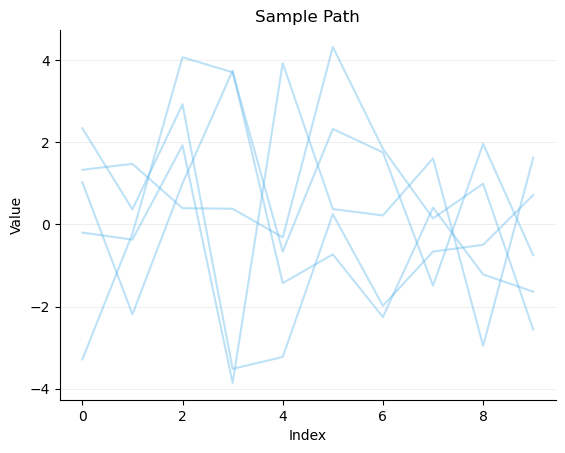

In [10]:
GARCH(omega=0.2, arch_coefs=[0.05], garch_coefs=[0.9]).sim(5).plot()   # persistent

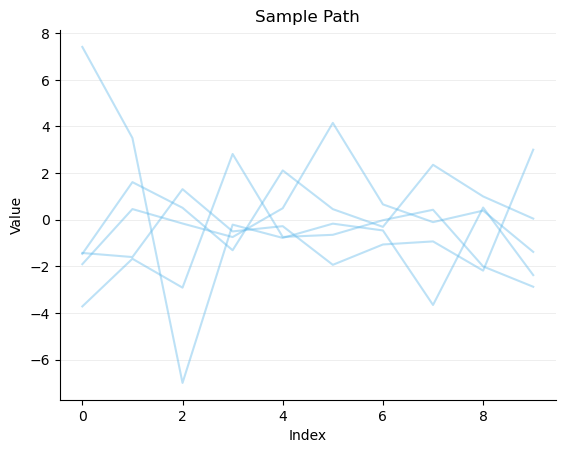

In [11]:
GARCH(omega=2.0, arch_coefs=[0.6], garch_coefs=[0.2]).sim(5).plot()   # jumpy

## ARCH: the version without persistence

Drop the `garch_coefs` and you get the original ARCH model, where the variance depends only
on recent squared values and forgets after `len(coefs)` steps. A GARCH usually fits real
data with far fewer parameters than a long ARCH, which is why it replaced it.

In [12]:
A = ARCH(omega=0.5, coefs=[0.5])
round(A.initial, 2), A.garch_coefs

(1.0, [])

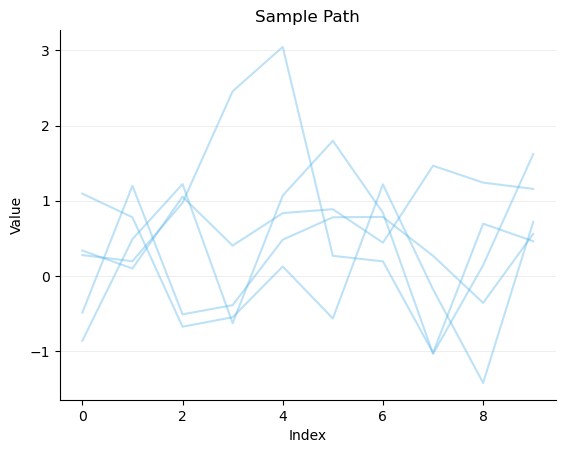

In [13]:
A.sim(5).plot()

## When the variance never settles

Coefficients summing to 1 or more are allowed, and simulate fine -- the variance simply
grows instead of settling. There is no long-run variance in that case, so Symbulate starts
from $\omega$ and the spread widens as you go.

In [14]:
E = GARCH(omega=0.2, arch_coefs=[0.2], garch_coefs=[0.9])

for n in [0, 5, 15, 30]:
    print("n =", n, " variance", round(E[n].sim(4000).var(), 1))

n = 0  variance 0.4


n = 5  variance 1.9


n = 15  variance 8.1


n = 30  variance 41.1
